In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import inspect
import pickle

import torch
from PIL import Image
from torchvision.transforms.functional import to_pil_image

from anomalib.visualization.image.functional import (
    get_field_kwargs,
    overlay_image,
    overlay_images,
    visualize_anomaly_map,
    visualize_mask,
)

with open("item.pkl", "rb") as f:
    item = pickle.load(f)


/home/sakcay/.pyenv/versions/anomalib/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [ ]:
get_field_kwargs(field="mask")

In [ ]:
get_field_kwargs(field="gt_mask")

In [ ]:
get_field_kwargs(field="anomaly_map")

In [3]:
# Get image and mask
image = Image.open(item.image_path).resize((256, 256))
mask = to_pil_image(item.gt_mask.to(torch.uint8) * 255)

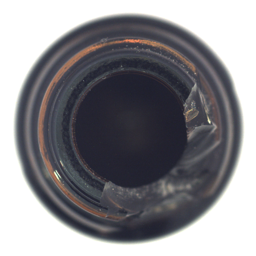

In [4]:
image

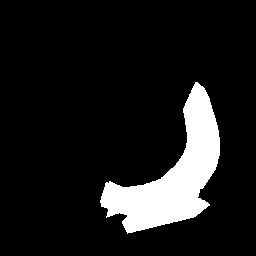

In [5]:
visualize_mask(item.gt_mask, mode="binary", color=(255, 0, 0), alpha=0.1)

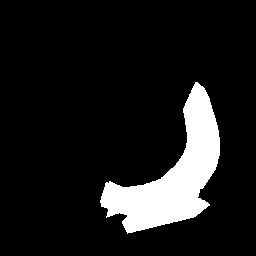

In [6]:
visualize_mask(item.gt_mask, mode="L")

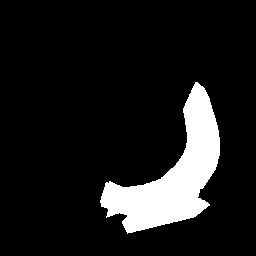

In [7]:
visualize_mask(item.gt_mask, mode="1")

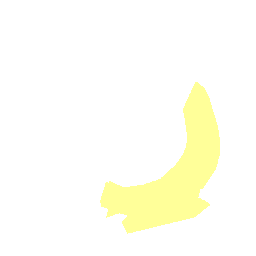

In [8]:
visualize_mask(item.gt_mask, mode="fill", color=(255, 255, 0), alpha=0.4)

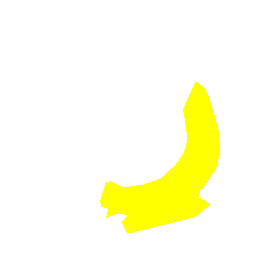

In [9]:
mask = visualize_mask(item.gt_mask, mode="fill", color=(255, 255, 0), alpha=1.0)
mask

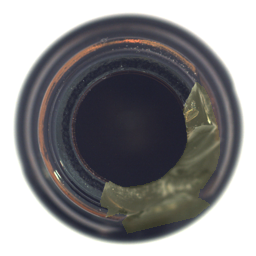

In [10]:
overlay_images(image, mask, alpha=0.1)

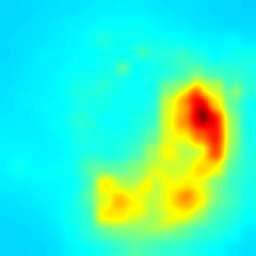

In [11]:
anomaly_map = visualize_anomaly_map(item.anomaly_map)
anomaly_map

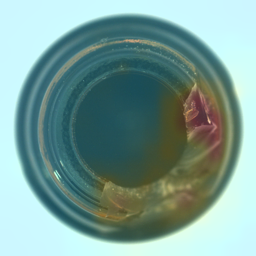

In [12]:
overlay_images(image, anomaly_map, alpha=0.2)

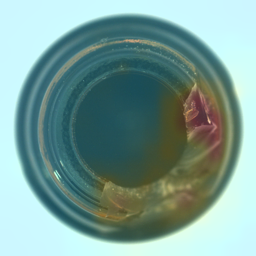

In [13]:
overlay_image(image, anomaly_map, alpha=0.2)

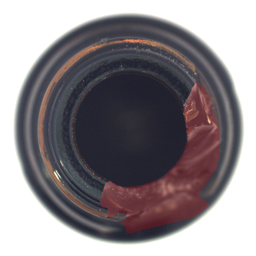

In [14]:
filled_mask = visualize_mask(item.gt_mask, mode="fill", color=(255, 0, 0), alpha=1)
overlay_image(image, filled_mask, alpha=0.2)


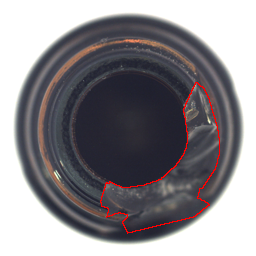

In [15]:
contour_mask = visualize_mask(item.gt_mask, mode="contour", color=(255, 0, 0), alpha=1)
overlay_image(image, contour_mask, alpha=1)

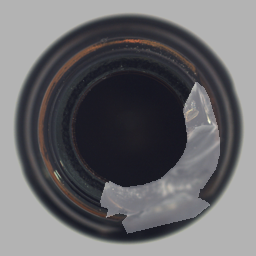

In [16]:
binary_mask = visualize_mask(item.gt_mask, mode="binary")
overlay_image(image, binary_mask, alpha=0.3)

In [ ]:
from __future__ import annotations

import torch
from PIL import Image
from typing import List, Protocol, runtime_checkable, Union, Tuple
from dataclasses import dataclass
import pytorch_lightning as pl


@runtime_checkable
class VisualizationStep(Protocol):
    def __call__(self, *values: torch.Tensor) -> Image.Image: ...


@dataclass
class BaseImageRenderer:
    def __call__(self, value: torch.Tensor) -> Image.Image:
        return to_pil_image(value)


@dataclass
class MaskRenderer:
    mode: str = "binary"
    color: tuple[int, int, int] = (255, 0, 0)
    alpha: float = 0.5
    background_color: tuple[int, int, int, int] = (0, 0, 0, 0)

    def __call__(self, value: torch.Tensor) -> Image.Image:
        return visualize_mask(
            value, mode=self.mode, color=self.color, alpha=self.alpha, background_color=self.background_color
        )


@dataclass
class AnomalyMapRenderer:
    normalize: bool = False
    colormap: bool = True

    def __call__(self, value: torch.Tensor) -> Image.Image:
        return visualize_anomaly_map(value, normalize=self.normalize, colormap=self.colormap)


@dataclass
class ImageOverlay:
    base_renderer: VisualizationStep
    overlay_renderer: VisualizationStep
    alpha: float = 0.5

    def __call__(self, base_value: torch.Tensor, overlay_value: torch.Tensor) -> Image.Image:
        base_image = self.base_renderer(base_value)
        overlay_image = self.overlay_renderer(overlay_value)
        return overlay_images(base_image, overlay_image, alpha=self.alpha)


class VisualizationPipeline:
    def __init__(self, steps: List[Tuple[Union[str, Tuple[str, ...]], VisualizationStep]]):
        self.steps = steps

    def __call__(self, item: dict[str, torch.Tensor]) -> List[Image.Image]:
        images = []
        for fields, step in self.steps:
            if isinstance(fields, str):
                fields = (fields,)
            values = [item.get(field) for field in fields]
            if any(value is None for value in values):
                raise ValueError(f"One or more fields not found in the input item: {fields}")
            image = step(*values)
            images.append(image)
        return images


def create_visualization_pipeline(
    *args: Tuple[Union[str, Tuple[str, ...]], VisualizationStep],
) -> VisualizationPipeline:
    return VisualizationPipeline(list(args))


# Example usage
visualization_pipeline = create_visualization_pipeline(
    ("image", BaseImageRenderer()),
    (
        ("image", "anomaly_map"),
        ImageOverlay(BaseImageRenderer(), AnomalyMapRenderer(normalize=True, colormap=True), alpha=0.7),
    ),
    (
        ("image", "gt_mask"),
        ImageOverlay(BaseImageRenderer(), MaskRenderer(mode="contour", color=(0, 255, 0)), alpha=0.5),
    ),
    (
        ("image", "pred_mask"),
        ImageOverlay(BaseImageRenderer(), MaskRenderer(mode="fill", color=(255, 0, 0), alpha=0.3), alpha=0.5),
    ),
)
